
Initial Shape: (250000, 23)
After Cleaning: (133696, 23)
Outliers handled


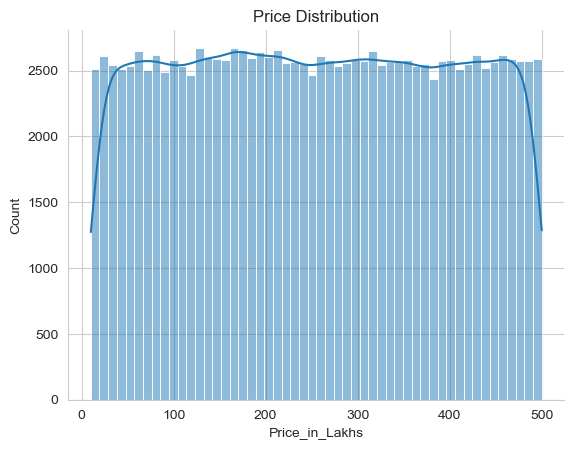

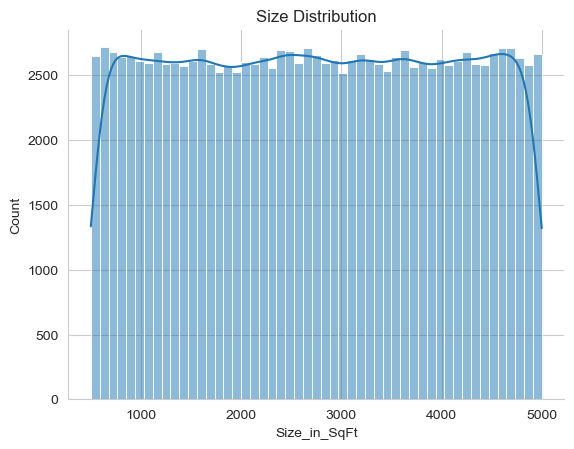

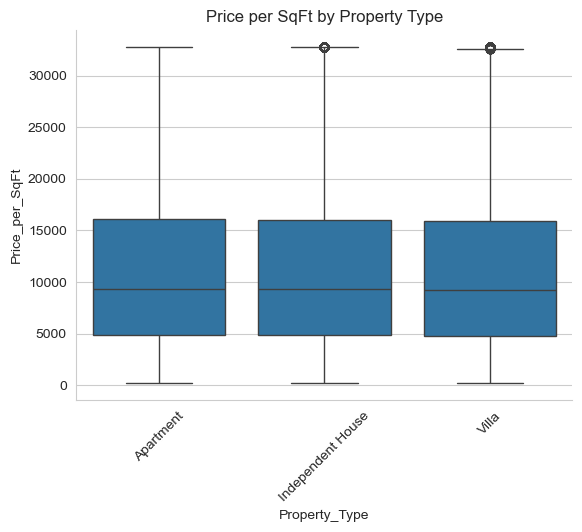

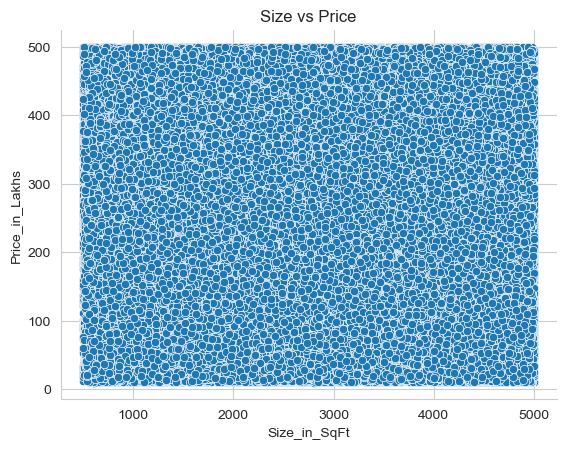

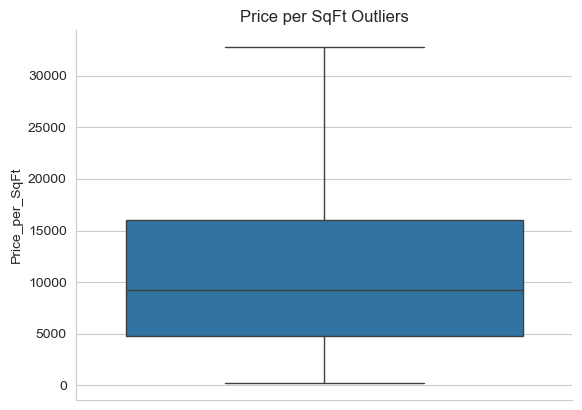

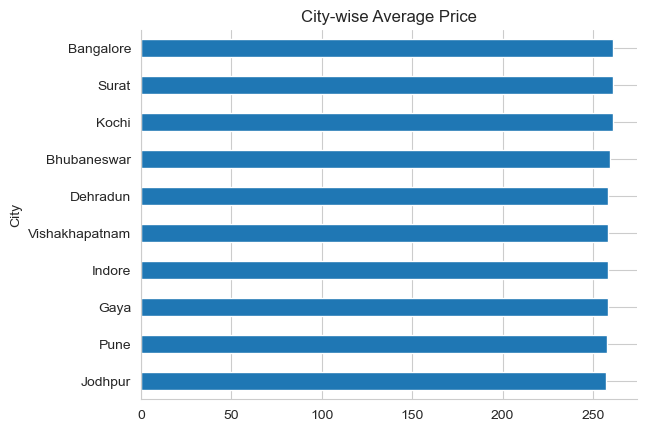

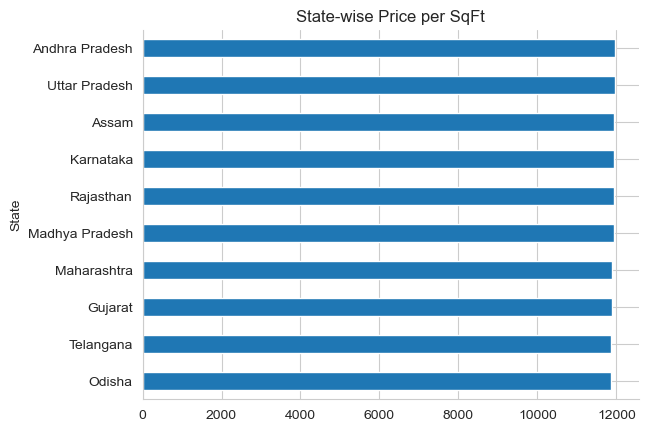

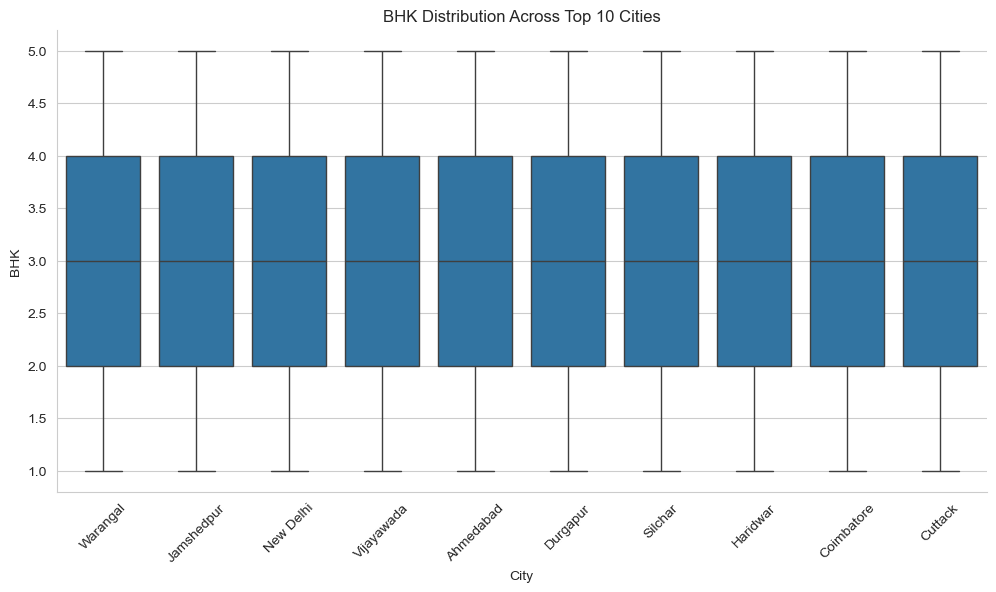

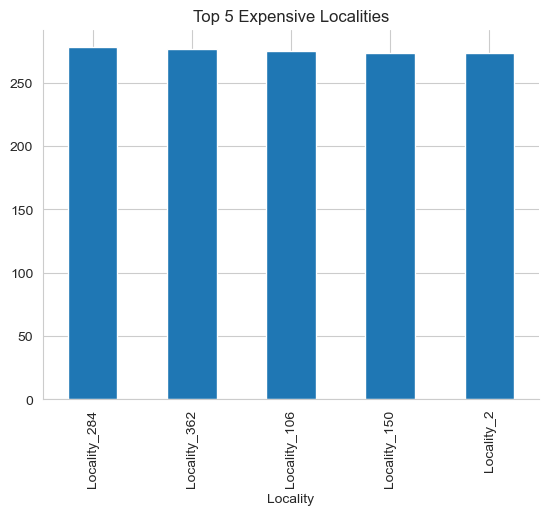

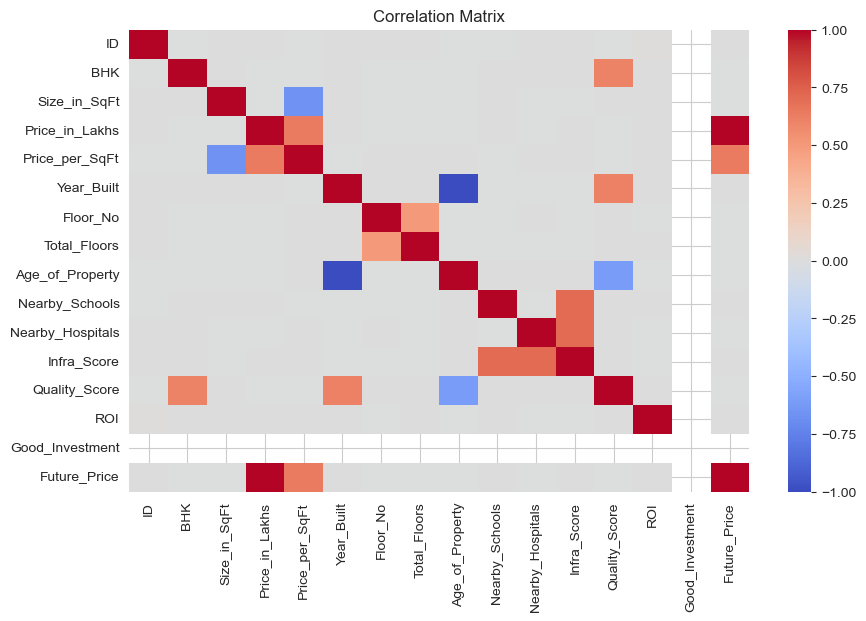

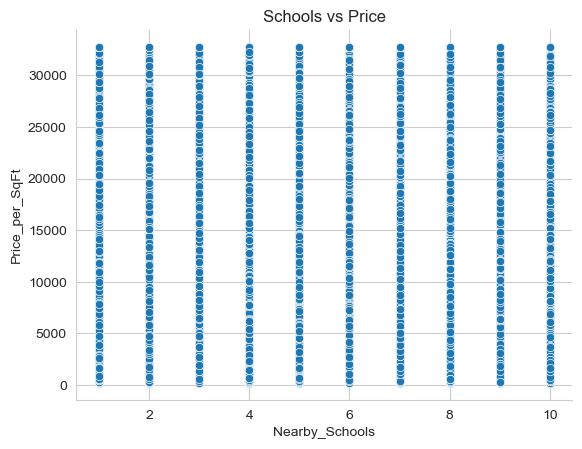

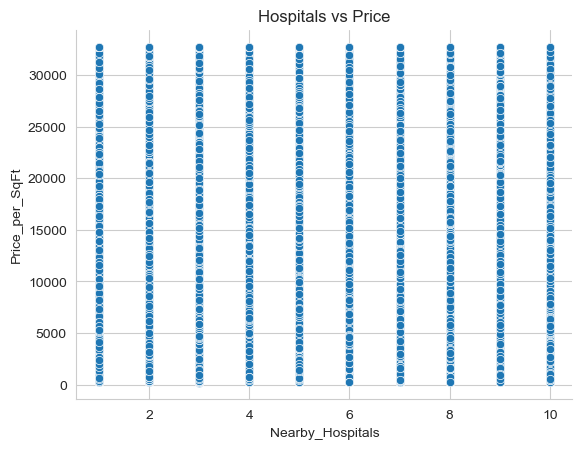

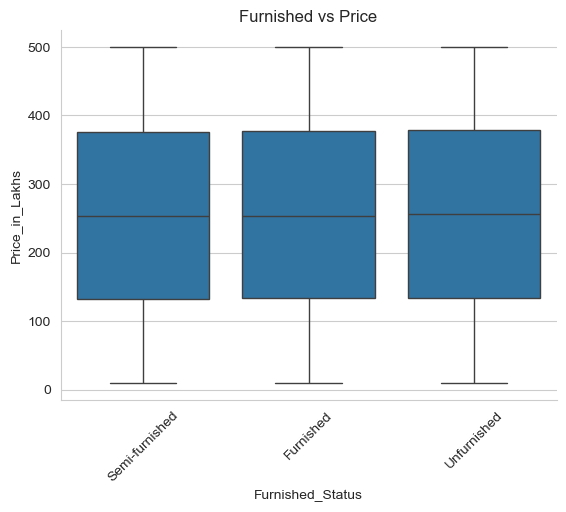

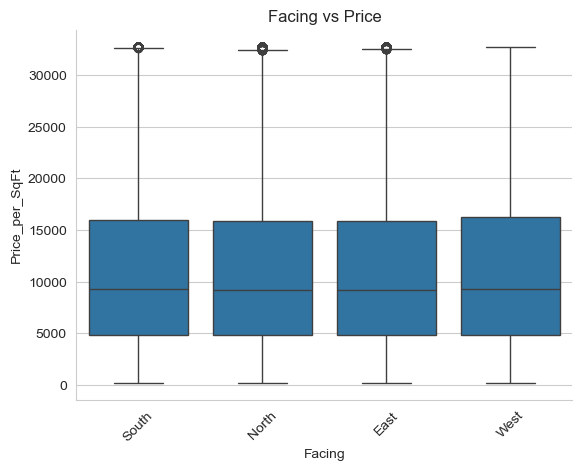

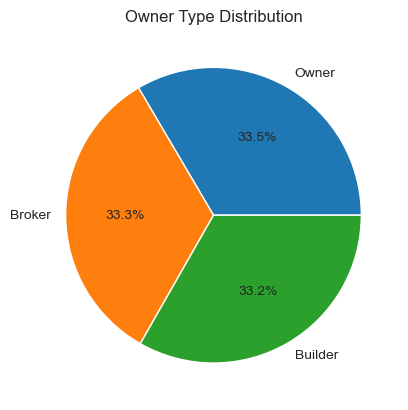

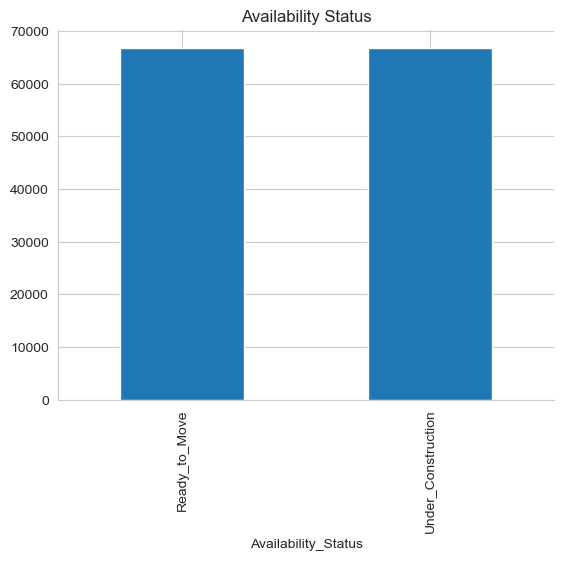

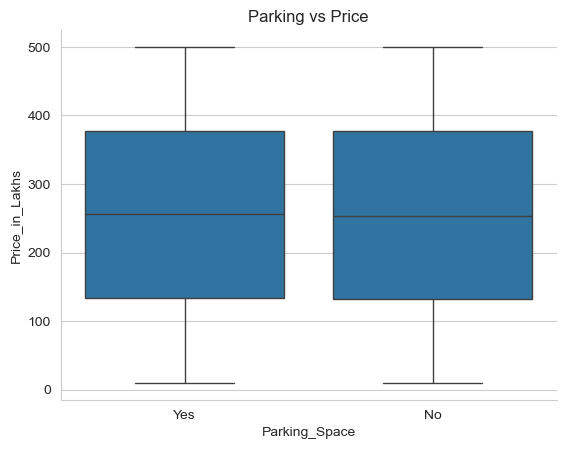

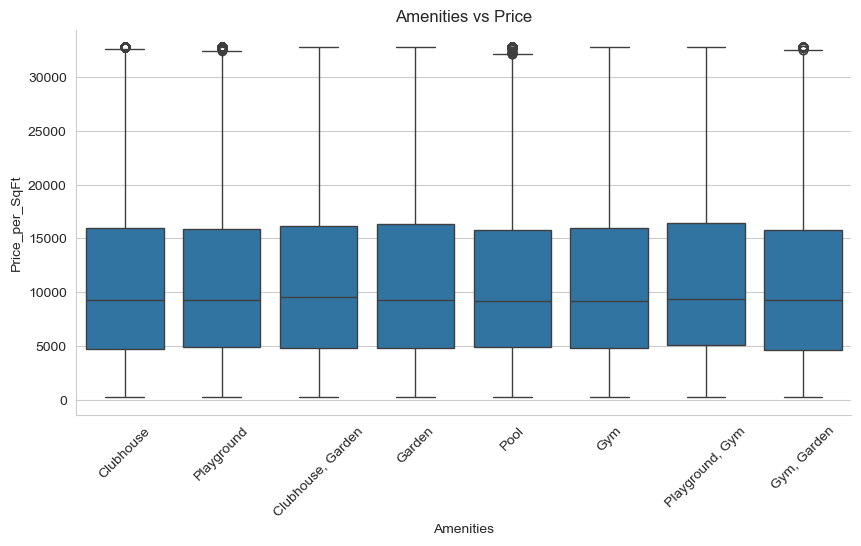

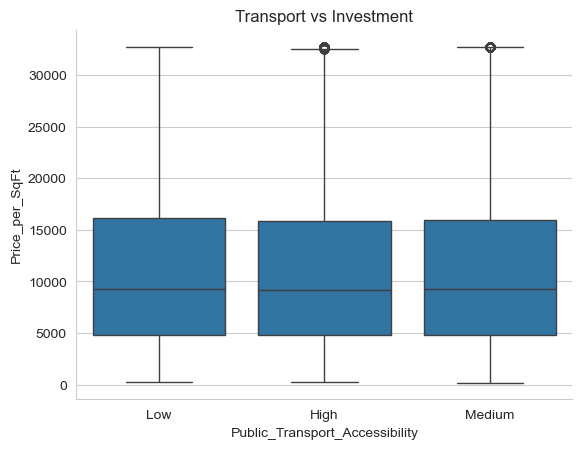

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv("../data/india_housing_prices.csv")

print("\nInitial Shape:", df.shape)

# ==========================================
# 2. CLEANING
# ==========================================

df = df[df["Floor_No"] <= df["Total_Floors"]]
df = df[df["Size_in_SqFt"] > 0]
df = df[df["Price_in_Lakhs"] > 0]
df = df[df["BHK"] > 0]
df = df[df["Year_Built"] <= 2025]

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

print("After Cleaning:", df.shape)

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================

current_year = 2025

df["Age_of_Property"] = current_year - df["Year_Built"]

df["Price_per_SqFt"] = df["Price_in_Lakhs"] * 100000 / (df["Size_in_SqFt"] + 1)

df["Infra_Score"] = df["Nearby_Schools"] + df["Nearby_Hospitals"]

df["Quality_Score"] = (
    (df["BHK"] >= 3).astype(int) +
    (df["Age_of_Property"] < 20).astype(int)
)

df["ROI"] = (df["Price_in_Lakhs"] * 1.35 - df["Price_in_Lakhs"]) / df["Price_in_Lakhs"]

df["Good_Investment"] = (df["ROI"] > 0.25).astype(int)

df["Future_Price"] = df["Price_in_Lakhs"] * (1.08 ** 5)

# ==========================================
# 4. OUTLIER CAPPING
# ==========================================

def cap_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    return df

for col in ["Price_in_Lakhs", "Size_in_SqFt", "Price_per_SqFt"]:
    df = cap_outliers(df, col)

print("Outliers handled")

# ==========================================
# 5. CLEAN PLOT STYLE (NO HEAVY BORDERS)
# ==========================================

def clean_plot():
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

# ==========================================
# 1–5 PRICE & SIZE ANALYSIS
# ==========================================

plt.figure()
sns.histplot(df["Price_in_Lakhs"], kde=True)
clean_plot()
plt.title("Price Distribution")
plt.show()

plt.figure()
sns.histplot(df["Size_in_SqFt"], kde=True)
clean_plot()
plt.title("Size Distribution")
plt.show()

plt.figure()
sns.boxplot(x="Property_Type", y="Price_per_SqFt", data=df)
clean_plot()
plt.xticks(rotation=45)
plt.title("Price per SqFt by Property Type")
plt.show()

plt.figure()
sns.scatterplot(x="Size_in_SqFt", y="Price_in_Lakhs", data=df)
clean_plot()
plt.title("Size vs Price")
plt.show()

plt.figure()
sns.boxplot(df["Price_per_SqFt"])
clean_plot()
plt.title("Price per SqFt Outliers")
plt.show()

# ==========================================
#  6–10 LOCATION ANALYSIS
# ==========================================

df.groupby("City")["Price_in_Lakhs"].mean().sort_values().tail(10).plot(kind="barh")
clean_plot()
plt.title("City-wise Average Price")
plt.show()

df.groupby("State")["Price_per_SqFt"].mean().sort_values().tail(10).plot(kind="barh")
clean_plot()
plt.title("State-wise Price per SqFt")
plt.show()

top_10_cities = df["City"].value_counts().head(10).index

filtered_df = df[df["City"].isin(top_10_cities)]

plt.figure(figsize=(12,6))

sns. boxplot(
    x="City",
    y="BHK",
    data=filtered_df
)

clean_plot()

plt.xticks(rotation=45)
plt.title("BHK Distribution Across Top 10 Cities")

plt.show()

top_localities = df.groupby("Locality")["Price_in_Lakhs"].mean().sort_values(ascending=False).head(5)

plt.figure()
top_localities.plot(kind="bar")
clean_plot()
plt.title("Top 5 Expensive Localities")
plt.show()

# ==========================================
# 11–15 CORRELATION
# ==========================================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

plt.figure()
sns.scatterplot(x="Nearby_Schools", y="Price_per_SqFt", data=df)
clean_plot()
plt.title("Schools vs Price")
plt.show()

plt.figure()
sns.scatterplot(x="Nearby_Hospitals", y="Price_per_SqFt", data=df)
clean_plot()
plt.title("Hospitals vs Price")
plt.show()

plt.figure()
sns.boxplot(x="Furnished_Status", y="Price_in_Lakhs", data=df)
clean_plot()
plt.xticks(rotation=45)
plt.title("Furnished vs Price")
plt.show()

plt.figure()
sns.boxplot(x="Facing", y="Price_per_SqFt", data=df)
clean_plot()
plt.xticks(rotation=45)
plt.title("Facing vs Price")
plt.show()

# ==========================================
# 16–20 INVESTMENT ANALYSIS
# ==========================================

df["Owner_Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Owner Type Distribution")
plt.ylabel("")
plt.show()

df["Availability_Status"].value_counts().plot(kind="bar")
clean_plot()
plt.title("Availability Status")
plt.show()

plt.figure()
sns.boxplot(x="Parking_Space", y="Price_in_Lakhs", data=df)
clean_plot()
plt.title("Parking vs Price")
plt.show()

top_amenities = df["Amenities"].value_counts().head(8).index
filtered = df[df["Amenities"].isin(top_amenities)]

plt.figure(figsize=(10,5))
sns.boxplot(x="Amenities", y="Price_per_SqFt", data=filtered)
clean_plot()
plt.xticks(rotation=45)
plt.title("Amenities vs Price")
plt.show()

plt.figure()
sns.boxplot(x="Public_Transport_Accessibility", y="Price_per_SqFt", data=df)
clean_plot()
plt.title("Transport vs Investment")
plt.show()

# EDA Insights

**1. Price Distribution**
Property prices are uniformly spread from 0 to 500 Lakhs with no natural clustering. This indicates a synthetically balanced dataset rather than a real-world price distribution.

**2. Size Distribution**
Property sizes range evenly from 1,000 to 5,000 SqFt with consistent counts across all bins. No particular size segment dominates, confirming uniform data generation.

**3. Price per SqFt by Property Type**
Apartments, Independent Houses, and Villas all show similar median Price per SqFt around 10,000–15,000. Villas have slightly more high-end outliers above 30,000, suggesting rare luxury listings.

**4. Size vs Price**
The scatter plot shows a completely random cloud with no visible relationship between size and price. In real markets a positive trend is expected, making this a key limitation of the dataset.

**5. Price per SqFt Outliers**
The median Price per SqFt is around 10,000 with the IQR spanning 5,000–15,000. Extreme outliers exist above 25,000–30,000 and must be capped before model training.

**6. State-wise Price per SqFt**
Andhra Pradesh and Uttar Pradesh have the highest Price per SqFt, exceeding 10,000–12,000. Odisha and Telangana are at the lower end, offering more affordable investment options.

**7. City-wise Average Price**
Bangalore is the most expensive city with an average price near 250 Lakhs, while Jodhpur and Pune are among the most affordable. This city-level ranking is useful for investors targeting high-appreciation markets.

**8. Top 5 Expensive Localities**
The top 5 localities show nearly equal average prices with no single locality dramatically outpricing others. Premium localities are clustered in a narrow upper price band.

**9. BHK Distribution Across Top 10 Cities**
All top 10 cities show a consistent median BHK of around 3, with values ranging from 1 to 5. No city shows a strong preference for any particular BHK configuration.

**10. Correlation Matrix**
Price in Lakhs and Future Price 5Y are strongly correlated as expected since future price is derived from current price. Infrastructure features like schools and hospitals show very weak correlation with price individually.

**11. Schools vs Price per SqFt**
Nearby school count shows no meaningful trend with Price per SqFt, with prices spread uniformly at every school count level. School proximity alone is not a price driver in this dataset.

**12. Hospitals vs Price per SqFt**
Similar to schools, hospital count shows vertical band patterns with no upward or downward price trend. Proximity to hospitals does not significantly influence property pricing here.

**13. Furnished Status vs Price**
Semi-Furnished, Furnished, and Unfurnished properties all have nearly identical price distributions with medians around 250 Lakhs. Furnishing status is not a strong price differentiator in this dataset.

**14. Facing vs Price per SqFt**
South-facing properties show a marginally higher median Price per SqFt compared to North, East, and West. Overall the differences are minimal and facing direction has little pricing impact here.

**15. Owner Type Distribution**
Owner, Broker, and Builder listings are split almost equally at around 33% each. This perfectly balanced split reflects synthetic data, as real markets are typically dominated by broker listings.

**16. Availability Status**
Ready to Move and Under Construction properties are nearly equal in count at around 65,000 each. For investors, Ready to Move eliminates construction risk while Under Construction offers lower entry prices.

**17. Parking Space vs Price**
Properties with parking show a slightly higher median price than those without, but the difference is marginal. Parking availability has minimal impact on price in this dataset despite being a valued amenity.

**18. Amenities vs Price per SqFt**
All amenity types including Clubhouse, Pool, Gym, and Garden show consistent Price per SqFt around 10,000–15,000. No single amenity commands a clear price premium in this dataset.

**19. Transport vs Investment**
Low, Medium, and High public transport accessibility categories show nearly identical Price per SqFt distributions. Transport access does not drive pricing here, unlike real markets where metro connectivity adds significant premiums.

**20. Good Investment Label (Correlation)**
The Good Investment label is moderately negatively correlated with price, confirming that cheaper properties score higher as good investments. This validates the multi-factor labelling logic used in feature engineering.